In [1]:
import os
import numpy as np
import numpy.linalg as LA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import xgboost as xgb
from sklearn.model_selection import GridSearchCV



In [2]:
BASE_PATH = "/kaggle/input/nomad2018-predict-transparent-conductors"

df_train = pd.read_csv(os.path.join(BASE_PATH, "train.csv"))
df_train["dataset"] = "train"
df_test = pd.read_csv(os.path.join(BASE_PATH, "test.csv"))
df_test["dataset"] = "test"
test_len = len(df_test)
df = pd.concat([df_train, df_test], axis=0, ignore_index=True, sort=False)
df_len = len(df)



In [3]:
df.head()




,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree,formation_energy_ev_natom,bandgap_energy_ev,dataset
0,1,206,80.0,0.3125,0.6250,0.0625,9.3282,9.3279,9.3277,90.0047,90.0045,89.9950,0.1337,2.6562,train
1,2,206,80.0,1.0000,0.0000,0.0000,8.9847,8.9839,8.9843,90.0024,90.0036,89.9994,0.0738,5.2114,train
2,3,227,40.0,0.8125,0.0000,0.1875,5.8341,5.8343,14.3401,89.9999,89.9980,120.0005,0.3671,1.8353,train
3,4,12,20.0,0.2500,0.6250,0.1250,12.3144,3.0840,5.9539,89.9999,104.1046,90.0001,0.0698,2.3056,train
4,5,33,80.0,0.0000,0.1875,0.8125,11.1457,9.4822,10.1054,89.9994,89.9967,90.0000,0.1154,0.9503,train


In [4]:
def get_xyz(filename):
    xyz = []
    lattice = []
    with open(filename) as f:
        for line in f.readlines():
            parts = line.split()
            if not parts:
                continue
            if parts[0] == "atom":
                xyz.append((np.array(parts[1:4], dtype=float), parts[4]))
            elif parts[0] == "lattice_vector":
                lattice.append(np.array(parts[1:4], dtype=float))
    return xyz, lattice




In [5]:
def get_sine_matrix(xyz, lattice):
    """
    Build the sine‑matrix as described in the original notebook.
    Handles variable‑length xyz lists and maps element symbols to integer charges.
    """
    n_atom = len(xyz)
    if n_atom == 0:
        # return a 1×1 zero matrix for empty structures
        return np.zeros((1, 1))

    # separate coordinates and element symbols
    coords = np.stack([item[0] for item in xyz])  # (n_atom, 3)
    labels_str = np.array([item[1] for item in xyz])  # (n_atom,)

    # map element symbols to charges
    charge_map = {"O": 8, "Al": 13, "Ga": 31, "In": 49}
    labels = np.vectorize(charge_map.get)(labels_str).reshape(-1, 1).astype(float)

    # distance matrix via sine‑based metric
    distance_matrix = np.ones((n_atom, n_atom))
    A = np.transpose(np.stack(lattice))  # lattice matrix (3×3)
    B = LA.inv(A)  # inverse lattice

    for i in range(n_atom):
        for j in range(i):
            r_ij = np.dot(B, coords[i] - coords[j])
            sin_sq_r = (np.sin(np.pi * r_ij)) ** 2
            distance = LA.norm(np.dot(A, sin_sq_r))
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    # charge interaction matrix
    charge_matrix = np.dot(labels, labels.T)
    np.fill_diagonal(charge_matrix, 0.0)
    charge_matrix += np.diag(0.5 * (labels.squeeze() ** 2.4))

    # final sine matrix
    sine_matrix = charge_matrix / distance_matrix
    return sine_matrix




In [6]:
def get_eigenspectrum(matrix):
    spectrum = LA.eigvalsh(matrix)
    spectrum = np.sort(spectrum)[::-1]
    return spectrum




In [7]:
MAX_SPECTRUM_LEN = 80  # fixed length for all spectra
spectrum_list = []

for idx in range(df_len):
    dataset_label = df.dataset.values[idx]
    row_id = df.id.values[idx]
    filename = os.path.join(BASE_PATH, dataset_label, str(row_id), "geometry.xyz")
    if not os.path.isfile(filename):
        spectrum_list.append(np.zeros(MAX_SPECTRUM_LEN))
        continue
    xyz, lattice = get_xyz(filename)
    sine_matrix = get_sine_matrix(xyz, lattice)
    spectrum = get_eigenspectrum(sine_matrix)
    # pad / truncate to MAX_SPECTRUM_LEN
    if len(spectrum) < MAX_SPECTRUM_LEN:
        spectrum = np.pad(spectrum, (0, MAX_SPECTRUM_LEN - len(spectrum)), "constant")
    else:
        spectrum = spectrum[:MAX_SPECTRUM_LEN]
    spectrum_list.append(spectrum)



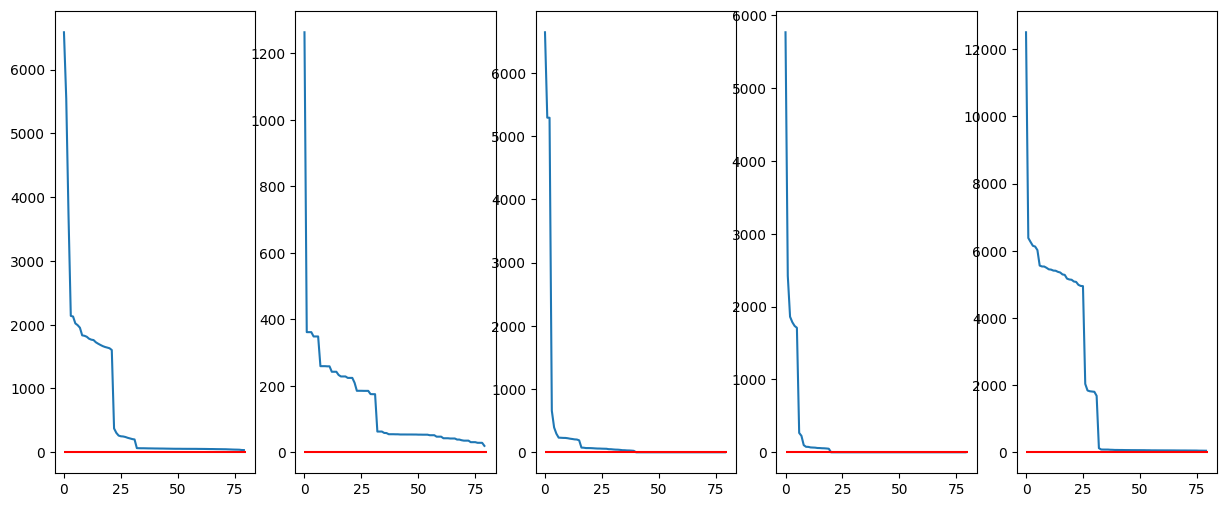

In [8]:
fig, axs = plt.subplots(1, 5, figsize=(15, 6))
for i in range(min(5, len(spectrum_list))):
    ax = axs[i]
    plot_data = spectrum_list[i]
    ax.plot(range(len(plot_data)), plot_data)
    ax.hlines(0, 0, MAX_SPECTRUM_LEN, colors="r")
plt.show()



In [9]:
spectrum_df = pd.DataFrame(spectrum_list).astype(float)



In [10]:
ss = StandardScaler()
spectrum_std = ss.fit_transform(spectrum_df.values)

n_components = min(30, spectrum_std.shape[1])  # a modest number of components
pca = PCA(n_components=n_components, random_state=42)
spectrum_pca = pd.DataFrame(pca.fit_transform(spectrum_std))



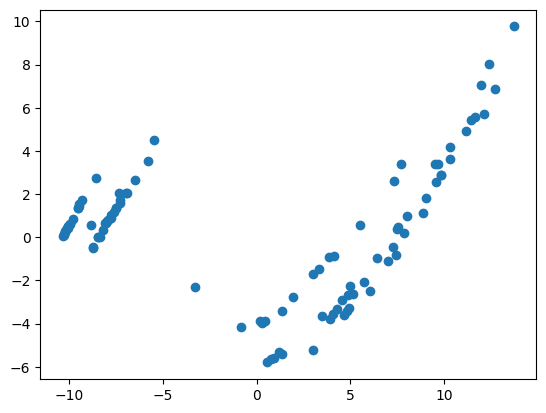

In [11]:
plt.scatter(x=spectrum_pca.iloc[:100, 0], y=spectrum_pca.iloc[:100, 1])
plt.show()



In [12]:
df["number_of_total_atoms"] = df["number_of_total_atoms"].astype(int)
df["group_natoms"] = (
    df["spacegroup"].astype(str) + "_" + df["number_of_total_atoms"].astype(str)
)



/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


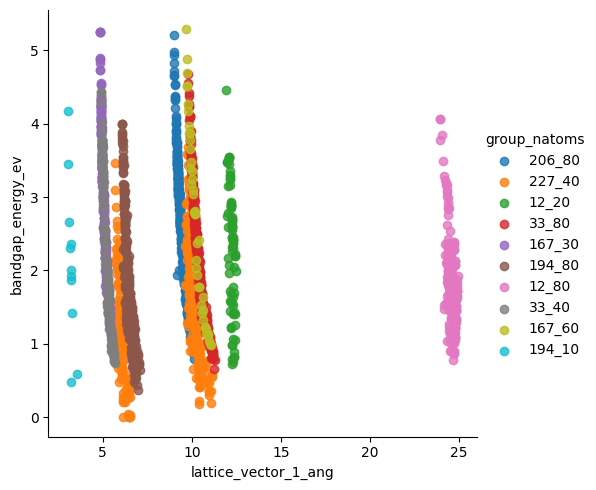

In [13]:
sns.lmplot(
    x="lattice_vector_1_ang",
    y="bandgap_energy_ev",
    hue="group_natoms",
    data=df,
    fit_reg=False,
)
plt.show()



In [14]:
df = df.join(pd.get_dummies(df["group_natoms"]))
df.drop(["group_natoms"], axis=1, inplace=True)



In [15]:
df.columns



Index(['id', 'spacegroup', 'number_of_total_atoms', 'percent_atom_al',
       'percent_atom_ga', 'percent_atom_in', 'lattice_vector_1_ang',
       'lattice_vector_2_ang', 'lattice_vector_3_ang',
       'lattice_angle_alpha_degree', 'lattice_angle_beta_degree',
       'lattice_angle_gamma_degree', 'formation_energy_ev_natom',
       'bandgap_energy_ev', 'dataset', '12_20', '12_80', '167_30', '167_60',
       '194_10', '194_80', '206_80', '227_40', '33_40', '33_80'],
      dtype='object')

In [16]:
df.drop(["dataset"], axis=1, inplace=True)
df.drop(["id", "spacegroup", "number_of_total_atoms"], axis=1, inplace=True)



In [17]:
df.columns



Index(['percent_atom_al', 'percent_atom_ga', 'percent_atom_in',
       'lattice_vector_1_ang', 'lattice_vector_2_ang', 'lattice_vector_3_ang',
       'lattice_angle_alpha_degree', 'lattice_angle_beta_degree',
       'lattice_angle_gamma_degree', 'formation_energy_ev_natom',
       'bandgap_energy_ev', '12_20', '12_80', '167_30', '167_60', '194_10',
       '194_80', '206_80', '227_40', '33_40', '33_80'],
      dtype='object')

In [18]:
df_new = pd.concat(
    [spectrum_pca.reset_index(drop=True), df.reset_index(drop=True)], axis=1
)
df_new.head()



,0,1,2,3,4,5,6,7,8,9,...,12_20,12_80,167_30,167_60,194_10,194_80,206_80,227_40,33_40,33_80
0,4.290977,-3.342168,1.825793,-0.803808,-0.902897,0.076415,-0.508365,0.856961,-0.267029,-0.335469,...,False,False,False,False,False,False,True,False,False,False
1,0.534186,-5.803486,3.654804,1.267651,-1.025637,0.655451,0.268948,-0.627120,0.423504,0.268472,...,False,False,False,False,False,False,True,False,False,False
2,-8.821037,0.582834,0.800401,0.760897,-0.075182,-0.060461,-0.520332,0.886016,-0.890025,-0.905298,...,False,False,False,False,False,False,False,True,False,False
3,-10.038860,0.527143,2.213544,-1.352517,-0.612079,-0.160412,0.895049,-0.111983,0.098636,0.159669,...,True,False,False,False,False,False,False,False,False,False
4,12.723067,6.856718,3.400310,0.865641,0.195799,0.162893,-0.197769,1.298142,1.706220,-1.579125,...,False,False,False,False,False,False,False,False,False,True


In [19]:
df_new.shape



(2400, 51)

In [20]:
df_len = len(df_new)
train_len = df_len - test_len

X = df_new.drop(["formation_energy_ev_natom", "bandgap_energy_ev"], axis=1).values
X_train = X[:train_len]
X_test = X[train_len:]

y_formation = df_new["formation_energy_ev_natom"].values[:train_len]
y_bandgap = df_new["bandgap_energy_ev"].values[:train_len]



In [21]:
xgb_formation = xgb.XGBRegressor(
    objective="reg:squarederror", n_jobs=4, random_state=42
)
parameters = {
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 200, 300],
}
cv_formation = GridSearchCV(xgb_formation, param_grid=parameters, cv=4, verbose=1)
cv_formation.fit(X_train, y_formation)



Fitting 4 folds for each of 9 candidates, totalling 36 fits


GridSearchCV(cv=4,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=4, num_parallel_tree=None,
                                    random_state=42, ...),
             param_grid={'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300]},
             verbose=1)

In [22]:
cv_formation.best_params_



{'max_depth': 2, 'n_estimators': 100}

In [23]:
xgb_bandgap = xgb.XGBRegressor(objective="reg:squarederror", n_jobs=4, random_state=42)
cv_bandgap = GridSearchCV(xgb_bandgap, param_grid=parameters, cv=4, verbose=1)
cv_bandgap.fit(X_train, y_bandgap)



Fitting 4 folds for each of 9 candidates, totalling 36 fits


GridSearchCV(cv=4,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=4, num_parallel_tree=None,
                                    random_state=42, ...),
             param_grid={'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300]},
             verbose=1)

In [24]:
cv_bandgap.best_params_




{'max_depth': 2, 'n_estimators': 200}

In [25]:
def plot_features(estimator, features):
    importances = estimator.feature_importances_
    plt.figure(figsize=(10, 15))
    plt.barh(range(len(importances)), importances, align="center")
    plt.yticks(np.arange(len(features)), features)
    plt.show()




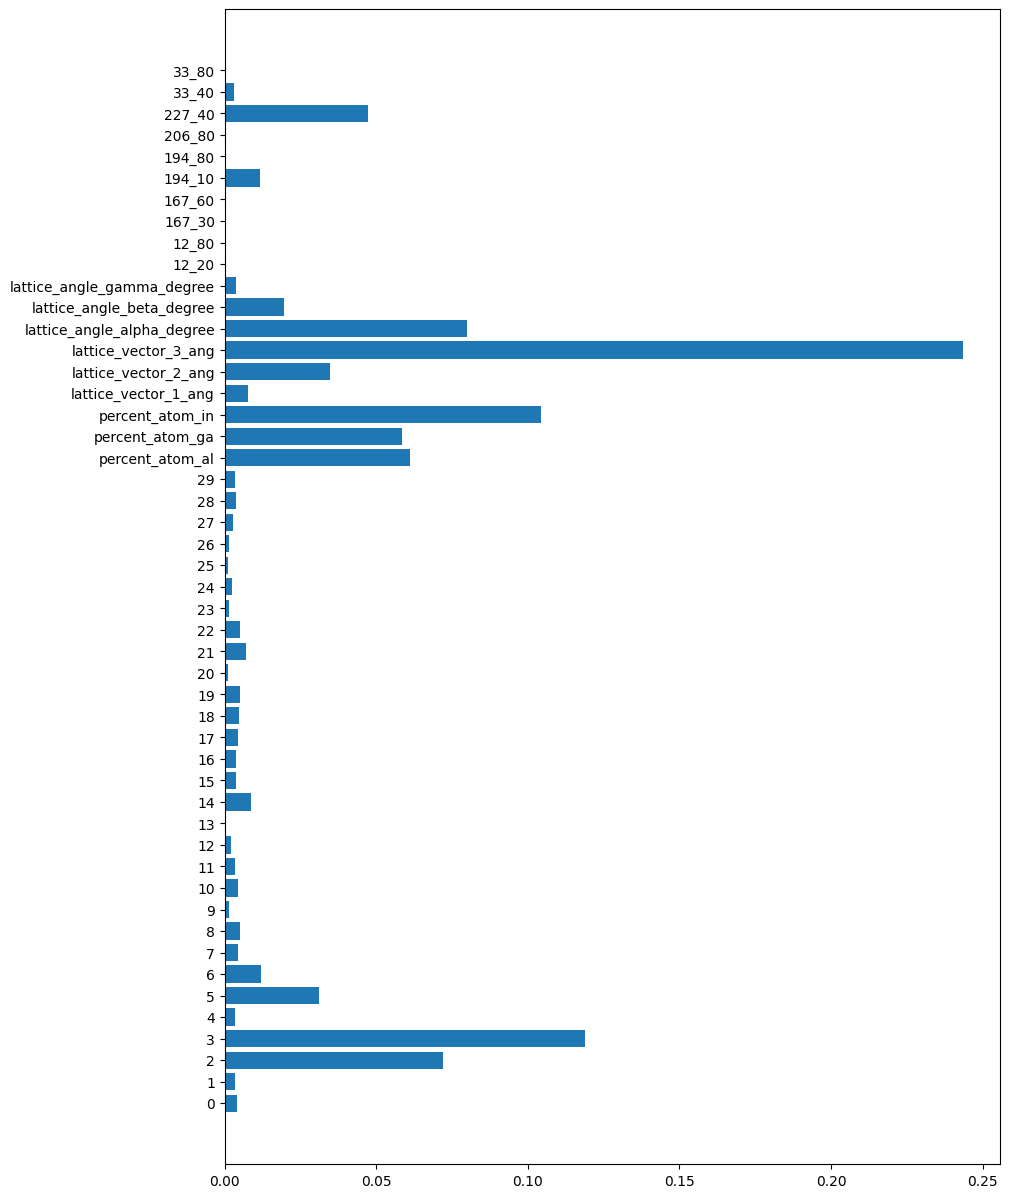

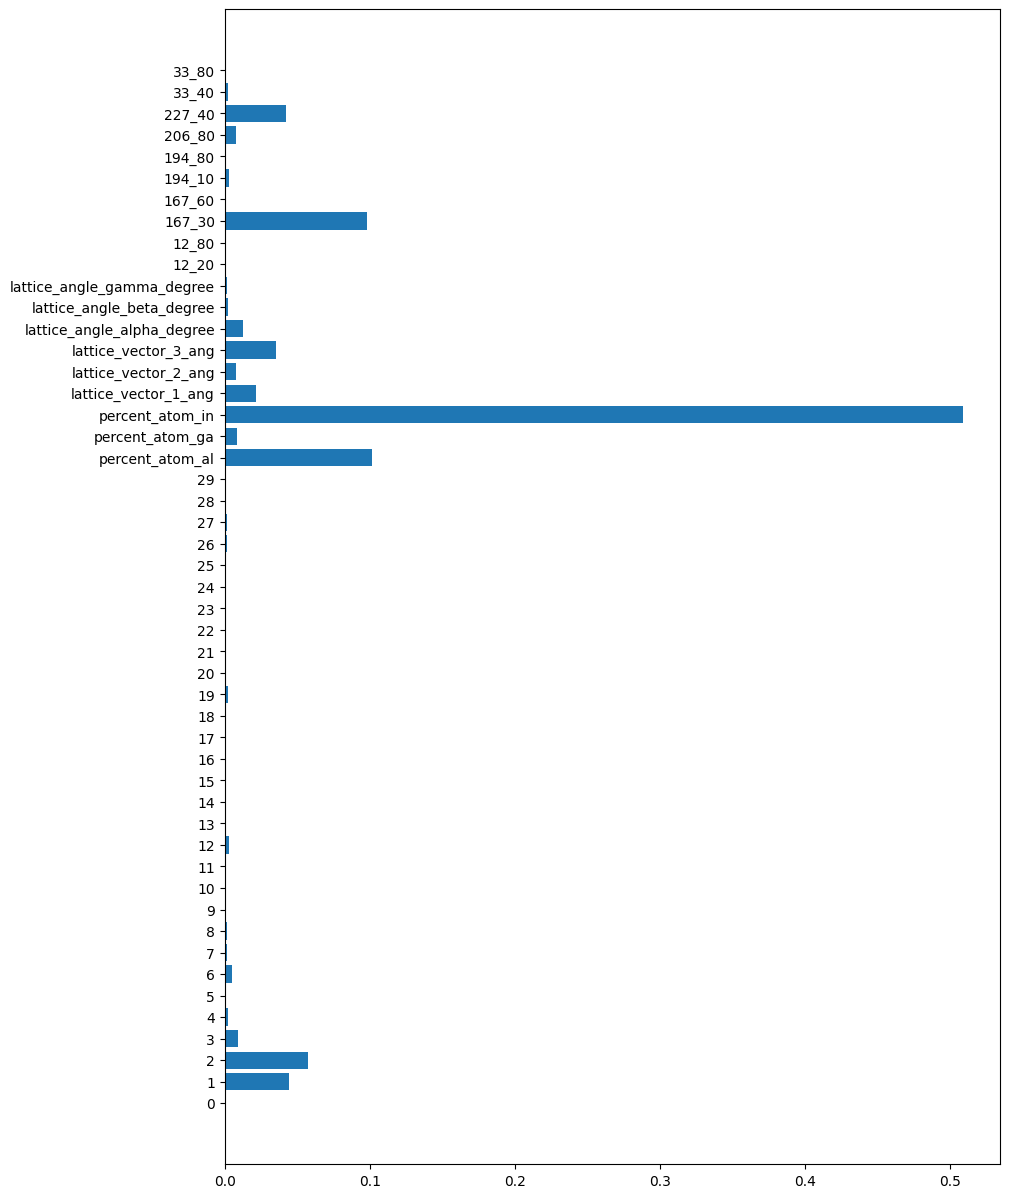

In [26]:
features = df_new.drop(
    ["formation_energy_ev_natom", "bandgap_energy_ev"], axis=1
).columns
plot_features(cv_formation.best_estimator_, features)
plot_features(cv_bandgap.best_estimator_, features)



In [27]:
formation_pred = cv_formation.predict(X_test)
bandgap_pred = cv_bandgap.predict(X_test)



In [28]:
submission = pd.DataFrame(
    {
        "id": df_test["id"].values,
        "formation_energy_ev_natom": formation_pred,
        "bandgap_energy_ev": bandgap_pred,
    }
)
submission.head()



,id,formation_energy_ev_natom,bandgap_energy_ev
0,1,0.234504,2.078894
1,2,0.255525,1.870055
2,3,0.101344,4.257807
3,4,0.041761,3.002004
4,5,0.396151,1.206186


In [29]:
submission.to_csv("submission.csv", index=False)